Loading California Housing Dataset

First 5 Rows:
   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude  MedHouseVal  
0    -122.23        4.526  
1    -122.22        3.585  
2    -122.24        3.521  
3    -122.25        3.413  
4    -122.25        3.422  

Dataset Shape: (20640, 9)

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MedInc       20640 non-null  float64
 1   HouseAge     20640 non-null  float64


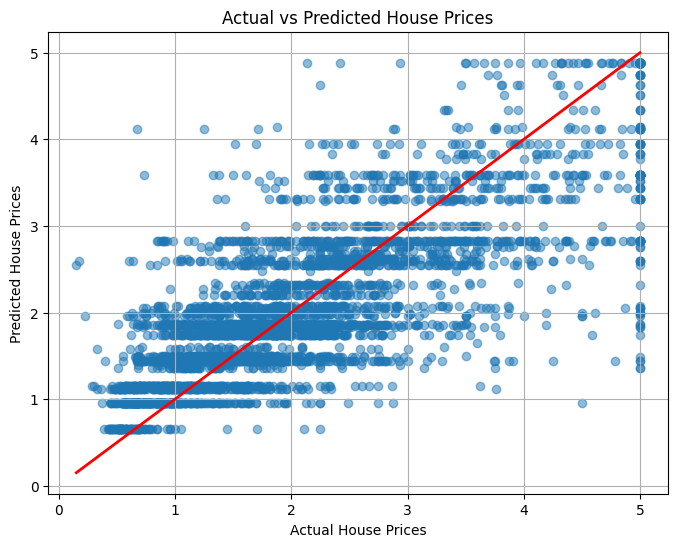

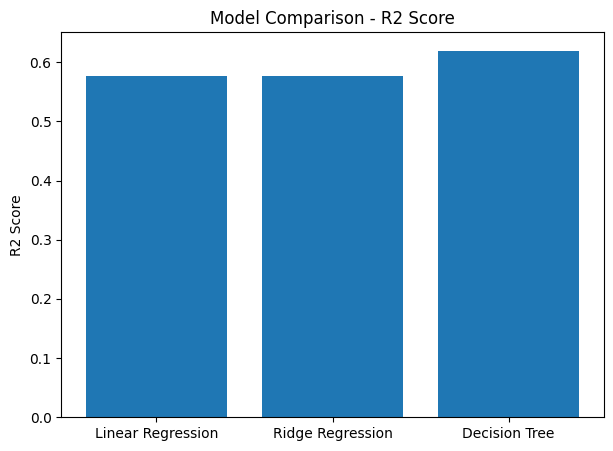

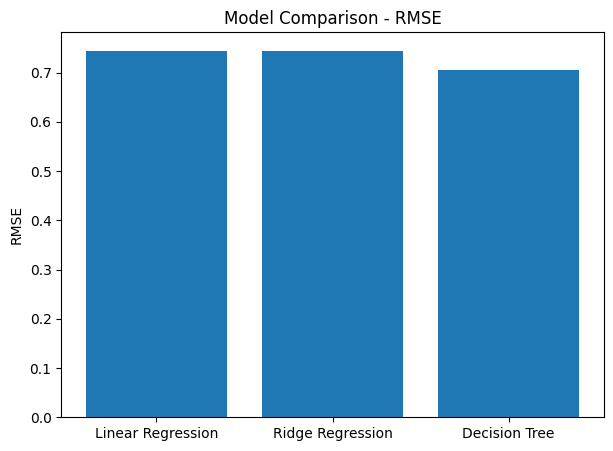


First 10 Predictions
   Actual Price  Predicted Price
0       0.47700         1.114809
1       0.45800         1.149831
2       5.00001         3.587274
3       2.18600         2.312972
4       2.78000         1.437985
5       1.58700         2.069800
6       1.98200         1.828577
7       1.57500         1.851330
8       3.40000         2.268379
9       4.46600         4.881880


FINAL RESULT
Best Model : Decision Tree
R2 Score : 0.6197
RMSE : 0.7059

Task-2 Completed Successfully!


In [1]:
# ============================================================
# AI & ML TASK-2
# Feature Engineering, Model Optimization & Performance Comparison
# California Housing Price Prediction
# ============================================================

# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, r2_score

# ============================================================
# Step 1: Load Dataset
# ============================================================

print("=" * 60)
print("Loading California Housing Dataset")
print("=" * 60)

housing = fetch_california_housing(as_frame=True)

df = housing.frame

print("\nFirst 5 Rows:")
print(df.head())

print("\nDataset Shape:", df.shape)

print("\nDataset Information:")
print(df.info())

print("\nStatistical Summary:")
print(df.describe())

# ============================================================
# Step 2: Feature Engineering
# ============================================================

print("\nCreating New Features...")

# New Features
df["RoomsPerHousehold"] = df["AveRooms"] / df["HouseAge"]
df["PopulationPerHousehold"] = df["Population"] / df["HouseAge"]

# Replace infinite values
df.replace([np.inf, -np.inf], np.nan, inplace=True)

# Fill missing values
df.fillna(df.mean(), inplace=True)

print("\nNew Features Added Successfully!")

# ============================================================
# Step 3: Separate Features and Target
# ============================================================

X = df.drop("MedHouseVal", axis=1)
y = df["MedHouseVal"]

# ============================================================
# Step 4: Feature Scaling
# ============================================================

print("\nApplying Standard Scaling...")

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

# ============================================================
# Step 5: Train Test Split
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.20,
    random_state=42
)

print("\nTraining Samples :", X_train.shape[0])
print("Testing Samples :", X_test.shape[0])

# ============================================================
# Step 6: Initialize Models
# ============================================================

models = {
    "Linear Regression": LinearRegression(),
    "Ridge Regression": Ridge(alpha=1.0),
    "Decision Tree": DecisionTreeRegressor(
        max_depth=6,
        random_state=42
    )
}

results = {}

print("\nTraining Models...\n")

# ============================================================
# Step 7: Train and Evaluate
# ============================================================

for name, model in models.items():

    print("-----------------------------------------")
    print(name)

    model.fit(X_train, y_train)

    predictions = model.predict(X_test)

    rmse = np.sqrt(mean_squared_error(y_test, predictions))
    r2 = r2_score(y_test, predictions)

    results[name] = {
        "RMSE": rmse,
        "R2 Score": r2
    }

    print("RMSE :", round(rmse, 4))
    print("R2 Score :", round(r2, 4))

# ============================================================
# Step 8: Results Table
# ============================================================

results_df = pd.DataFrame(results).T

print("\n")
print("=" * 60)
print("MODEL COMPARISON")
print("=" * 60)

print(results_df)

# ============================================================
# Step 9: Select Best Model
# ============================================================

best_model_name = results_df["R2 Score"].idxmax()

best_model = models[best_model_name]

print("\nBest Model :", best_model_name)

# ============================================================
# Step 10: Predictions
# ============================================================

y_pred = best_model.predict(X_test)

# ============================================================
# Step 11: Actual vs Predicted Graph
# ============================================================

plt.figure(figsize=(8,6))

plt.scatter(
    y_test,
    y_pred,
    alpha=0.5
)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color='red',
    linewidth=2
)

plt.xlabel("Actual House Prices")
plt.ylabel("Predicted House Prices")
plt.title("Actual vs Predicted House Prices")

plt.grid(True)

plt.show()

# ============================================================
# Step 12: R2 Score Comparison
# ============================================================

plt.figure(figsize=(7,5))

plt.bar(
    results_df.index,
    results_df["R2 Score"]
)

plt.title("Model Comparison - R2 Score")
plt.ylabel("R2 Score")

plt.show()

# ============================================================
# Step 13: RMSE Comparison
# ============================================================

plt.figure(figsize=(7,5))

plt.bar(
    results_df.index,
    results_df["RMSE"]
)

plt.title("Model Comparison - RMSE")
plt.ylabel("RMSE")

plt.show()

# ============================================================
# Step 14: Sample Predictions
# ============================================================

prediction_df = pd.DataFrame({
    "Actual Price": y_test.values,
    "Predicted Price": y_pred
})

print("\nFirst 10 Predictions")
print(prediction_df.head(10))

# ============================================================
# Final Output
# ============================================================

print("\n")
print("=" * 60)
print("FINAL RESULT")
print("=" * 60)

print("Best Model :", best_model_name)
print("R2 Score :", round(results_df.loc[best_model_name, "R2 Score"],4))
print("RMSE :", round(results_df.loc[best_model_name, "RMSE"],4))

print("\nTask-2 Completed Successfully!")
print("=" * 60)